In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import platform
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
import pickle


sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from data_processing import *
from utils import *

system = platform.system()

if system == 'Linux':
    home = '/home/gerard/data/confocal/'
elif system == 'Darwin':
    home = '/Users/gerard/data/confocal/'
elif system == "Windows":
    home = 'C:/Users/cviko/data/confocal/'

08-Jul-26 14:24:40 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


In [2]:
date = '2026_06_25'
user = 'Carmina'
info = describe_acquisition( home + date + '_' + user + '/Project.lif')


══════════════════════════════════════════════════════════════
Scene 0: dec02_1x_brain1alpha_R16
══════════════════════════════════════════════════════════════
  Objective  : HC PL APO CS2    63x/1.40 OIL
  NA / n     : 1.4 / 1.518
  Voxel size : XY = 0.0226 µm/px  |  Z = 0.1307 µm/step
  Shape      : 101 × 512 × 512  (Z × Y × X)

  ────────────────────────────────────── Acquisition sequences
  Seq 1  laser(s): 488 nm + 638 nm  [simultaneous]
         pinhole  : 95.47 µm  (0.999 AU)
         det ch1  501–610 nm  Leica/ALEXA 488         em = 519 nm
         det ch2  643–788 nm  Leica/Cy5               em = 670 nm
  Seq 2  laser(s): 552 nm
         pinhole  : 95.47 µm  (0.999 AU)
         det ch2  552–802 nm  (unnamed)               em = 570 nm

  ────────────────────────────────────── Image channels (0-indexed)
  ch0  Leica/ALEXA 488         em=519 nm  σ_xy=3.45px (0.078µm) [✓]  σ_z=2.03px [✓]  → 3D
  ch1  Leica/Cy5               em=670 nm  σ_xy=4.45px (0.101µm) [✓]  σ_z=2.62px [✓]  → 

In [6]:
loader2(date,user,False, False)

/Users/gerard/data/confocal/2026_06_25_Carmina
Number of series: 9
series 0: shape = (1, 3, 101, 512, 512)
series 1: shape = (1, 3, 71, 512, 512)
series 2: shape = (1, 3, 93, 512, 512)
series 3: shape = (1, 3, 71, 512, 512)
series 4: shape = (1, 3, 66, 512, 512)
series 5: shape = (1, 3, 112, 512, 512)
series 6: shape = (1, 3, 67, 512, 512)
series 7: shape = (1, 3, 62, 512, 512)
series 8: shape = (1, 3, 127, 512, 512)


### DECONVOLUTION :

In [3]:


path_data = date + '_' + user + '/Project.lif'
path_data_all = home + path_data #os.path.join(hom

print(path_data_all)
img = AICSImage(path_data_all)
# print(len(img.scenes))
# print(img.scenes[0])



/Users/gerard/data/confocal/2026_06_25_Carmina/Project.lif


#### serial version 

In [23]:



#scenes = list(range(len(info.keys())))
scenes = [0]
flagged2d= []
flagged3d = []
## DESIRED NUMBER OF ITERATIONS:
iterations = [
      #      1,        
            2,
            # #3,
            #4,
            # 5,
            #6,
            # # 7, 
            # 10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    for channel in channels:   
        stack = img.get_image_data("ZYX", T=0, C=channel)
        for num_iter in iterations:
            print(f'--------------> iteration {num_iter} for scene {scene} channel {channel}')
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter)
            flagged = analyze_deconvolution_results(result, stack)
            flagged3d.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter, forced2d = True)
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d.append(flagged)
            

--------------> iteration 2 for scene 0 channel 0
0.209 <------------------ pinhole
Applying pinhole factor 0.768 to PSF σ values: σ_xy 3.45 px → 2.65 px, σ_z 2.03 px → 1.56 px
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (2.65 px) | σ_z=0.265 µm (1.56 px) → 2D-per-frame (σ_z=1.56 px < 2, Z undersampled)
2026_06_05_s0_ch0_deconv2d_iter_2.tif
0.131 of inspected frames flagged
--------------> iteration 2 for scene 0 channel 1
0.16189701492537312 <------------------ pinhole
Applying pinhole factor 0.755 to PSF σ values: σ_xy 4.45 px → 3.36 px, σ_z 2.62 px → 1.98 px
PSF (ch1): λ=670 nm | σ_xy=0.101 µm (3.36 px) | σ_z=0.342 µm (1.98 px) → 2D-per-frame (σ_z=1.98 px < 2, Z undersampled)
2026_06_05_s0_ch1_deconv2d_iter_2.tif
0.000 of inspected frames flagged
--------------> iteration 2 for scene 0 channel 2
0.18930366492146594 <------------------ pinhole
Applying pinhole factor 0.763 to PSF σ values: σ_xy 3.81 px → 2.90 px, σ_z 2.24 px → 1.71 px
PSF (ch2): λ=573 nm | σ_xy=0.086 µm (2.90 px) | σ_z=0.293

#### parallelized version 

In [7]:
print(f'cpus: {os.cpu_count()}')


cpus: 10


In [10]:

n_jobs = os.cpu_count() - 2
print(f'n_jobs:{n_jobs}')
iterations = [
      #      1,        
            2,
            #3,
            #4,
            #5,
            # 6,
            # 7, 
            # 10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

scenes =  list(range(len(info.keys())))
# --- Phase 1: load all stacks sequentially (img is stateful) ---
stacks = {}
scene_channels = {}
for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    scene_channels[scene] = channels
    for channel in channels:
        stacks[(scene, channel)] = img.get_image_data("ZYX", T=0, C=channel)

# --- Phase 2: build flat job list ---
jobs = [
    (stacks[(scene, channel)], scene, channel, num_iter, forced2d)
    for scene in scenes
    for channel in scene_channels[scene]
    for num_iter in iterations
    for forced2d in [True]#[False, True]
]

def run_one(stack, scene, channel, num_iter, forced2d):
    result, sigma_xy_px = deconvolve(
        stack, path_data_all, channel=channel, scene=scene,
        num_iter=num_iter, forced2d=forced2d
    )
    flagged = analyze_deconvolution_results(result, stack)
    return (scene, channel, num_iter, forced2d, flagged)

# --- Run in parallel (threading shares imports & sys.path) ---
results = Parallel(n_jobs=n_jobs, backend='threading')(
    delayed(run_one)(*job) for job in jobs
)

# --- Reconstruct flagged lists ---
flagged3d = [r[-1] for r in results if not r[-2]]   # forced2d=False
flagged2d = [r[-1] for r in results if r[-2]]        # forced2d=True


n_jobs:8
0.7738522388059701 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 1.71 px → 1.60 px
PSF (ch1): λ=670 nm | σ_xy=0.094 µm (4.16 px) | σ_z=0.320 µm (1.60 px) → 2D-per-frame (σ_z=1.60 px, FORCED)
0.7738522388059701 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 2.62 px → 2.45 px
PSF (ch1): λ=670 nm | σ_xy=0.094 µm (4.16 px) | σ_z=0.320 µm (2.45 px) → 2D-per-frame (σ_z=2.45 px, FORCED)
0.7738522388059701 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 1.71 px → 1.60 px
PSF (ch1): λ=670 nm | σ_xy=0.094 µm (4.16 px) | σ_z=0.320 µm (1.60 px) → 2D-per-frame (σ_z=1.60 px, FORCED)
0.999 <------------------ pinhole
Applying pinhole factor 1.000 to PSF σ values: σ_xy 3.45 px → 3.45 px, σ_z 1.33 px → 1.33 px
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (3.45 px) | σ_z=0.265 µm (1.33 px) → 2D-per-frame (σ_z=1.33 px, FORCED)
0.999 <-----


### TRESHOLDING



| Method   |ch0: BRP (puncta)|ch1: HSP70 (diffuse) |ch2: Mitochondria| 
| --       | --              | --                  | --              |
| Otsu     | unstable        | weak performance    | good            |
| Triangle |  **very good**  | mediocre            | good            |
| Yen      | too strict      |often underestimates | ok              |
| Li       | good            |**best of the four** | good            |






[0, 1, 4, 5, 7, 8]
/Users/gerard/data/confocal/2026_06_25_Carmina/Project.lif
Processing series 0---------------
Channel 0************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_0/channel_0/2026_06_25_s0_ch0.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_0/channel_0/2026_06_25_s0_ch0_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_0/channel_0/2026_06_25_s0_ch0_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_0/channel_0/2026_06_25_s0_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_0/channel_1/2026_06_25_s0_ch1.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_0/channel_1/2026_06_25_s0_ch1_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_0/channel_1/2026_06_25_s

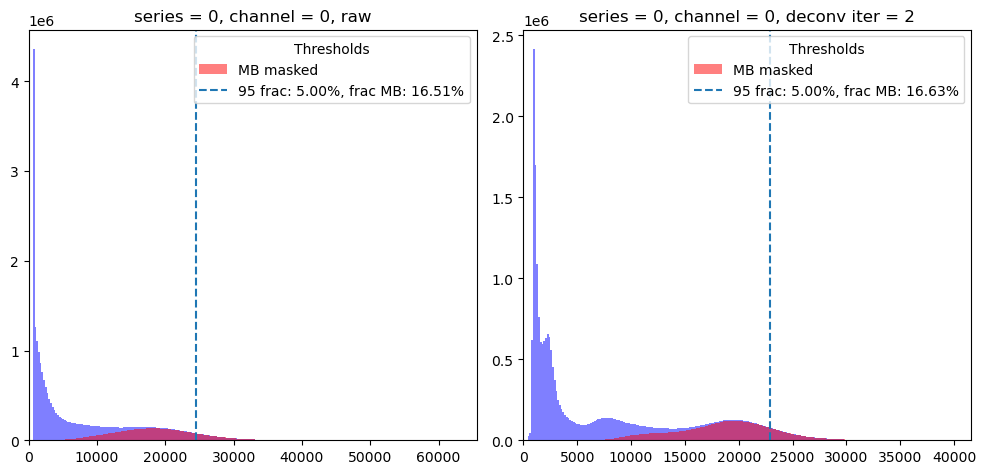

stack_deconv.shape: (101, 512, 512), MB_mask.shape: (101, 512, 512), stack_raw.shape: (101, 512, 512)


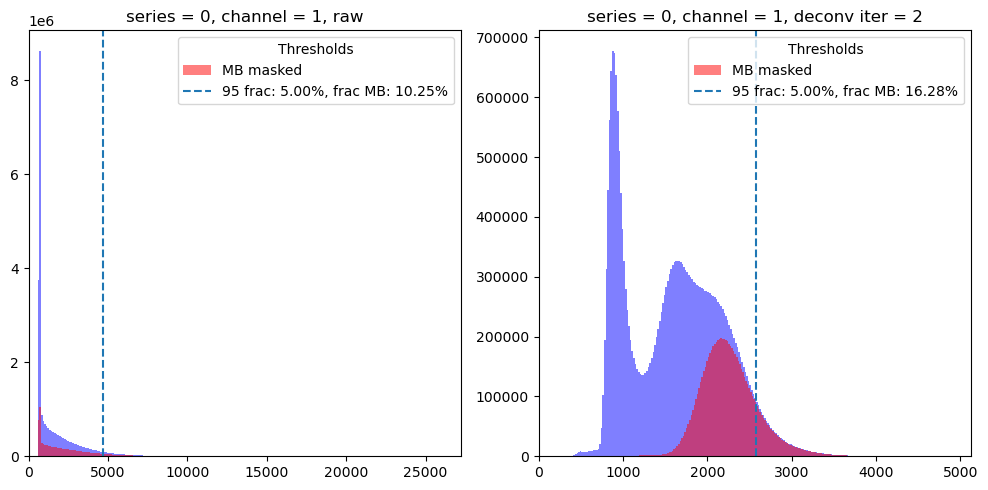

stack_deconv.shape: (101, 512, 512), MB_mask.shape: (101, 512, 512), stack_raw.shape: (101, 512, 512)


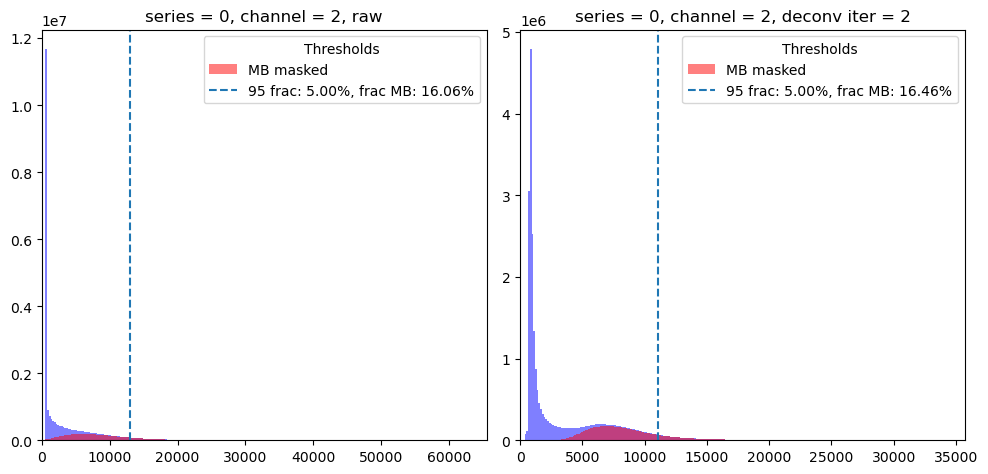

Processing series 1---------------
Channel 0************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_1/channel_0/2026_06_25_s1_ch0.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_1/channel_0/2026_06_25_s1_ch0_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_1/channel_0/2026_06_25_s1_ch0_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_1/channel_0/2026_06_25_s1_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_1/channel_1/2026_06_25_s1_ch1.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_1/channel_1/2026_06_25_s1_ch1_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_1/channel_1/2026_06_25_s1_ch1_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina

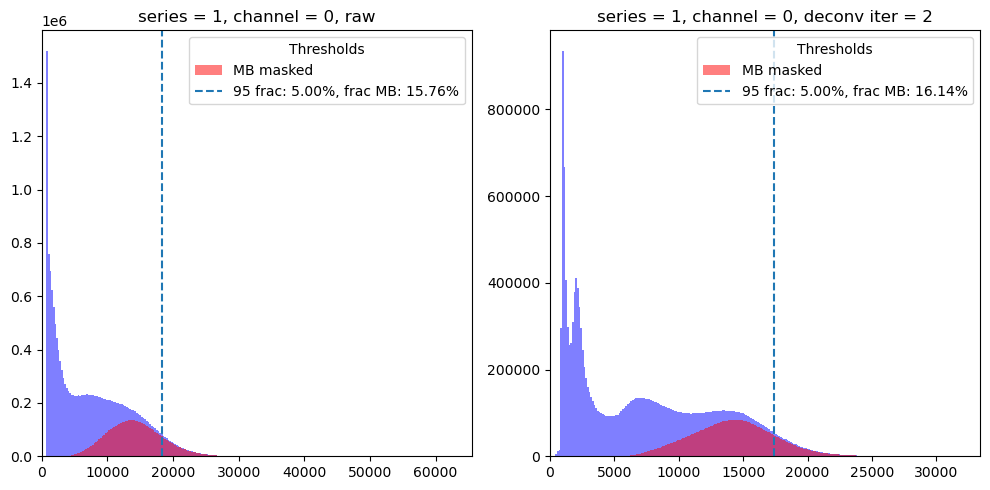

stack_deconv.shape: (71, 512, 512), MB_mask.shape: (71, 512, 512), stack_raw.shape: (71, 512, 512)


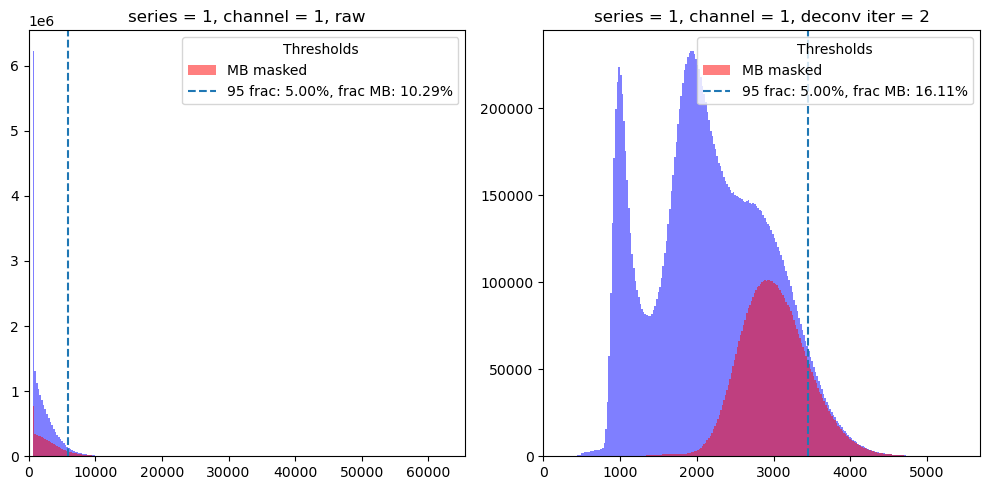

stack_deconv.shape: (71, 512, 512), MB_mask.shape: (71, 512, 512), stack_raw.shape: (71, 512, 512)


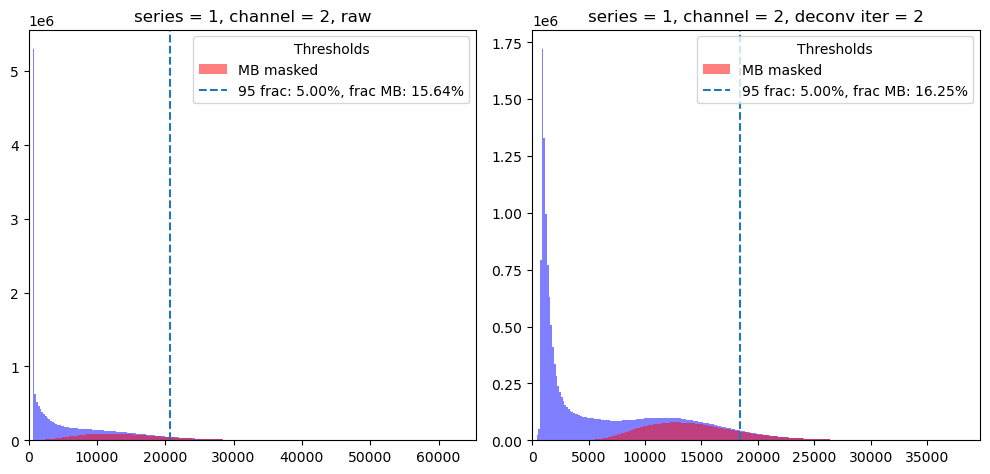

Processing series 4---------------
Channel 0************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_4/channel_0/2026_06_25_s4_ch0.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_4/channel_0/2026_06_25_s4_ch0_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_4/channel_0/2026_06_25_s4_ch0_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_4/channel_0/2026_06_25_s4_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_4/channel_1/2026_06_25_s4_ch1.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_4/channel_1/2026_06_25_s4_ch1_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_4/channel_1/2026_06_25_s4_ch1_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina

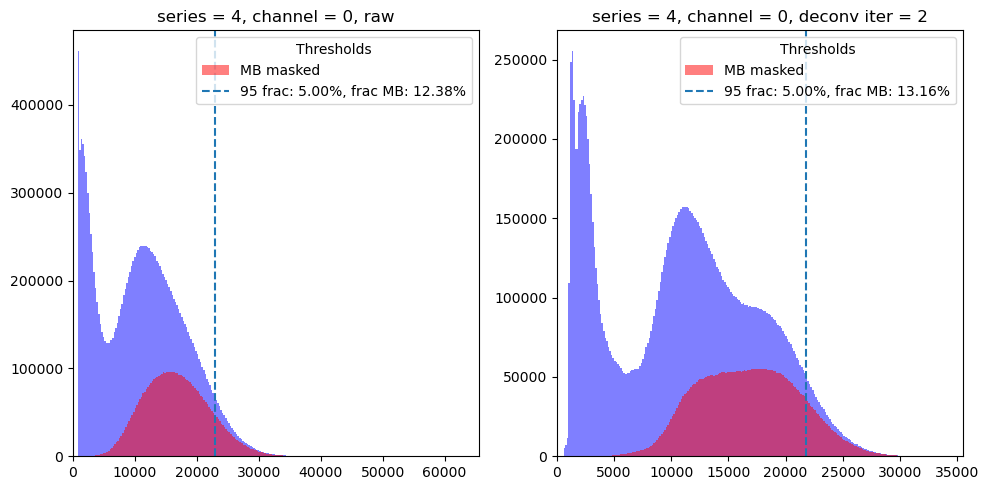

stack_deconv.shape: (66, 512, 512), MB_mask.shape: (66, 512, 512), stack_raw.shape: (66, 512, 512)


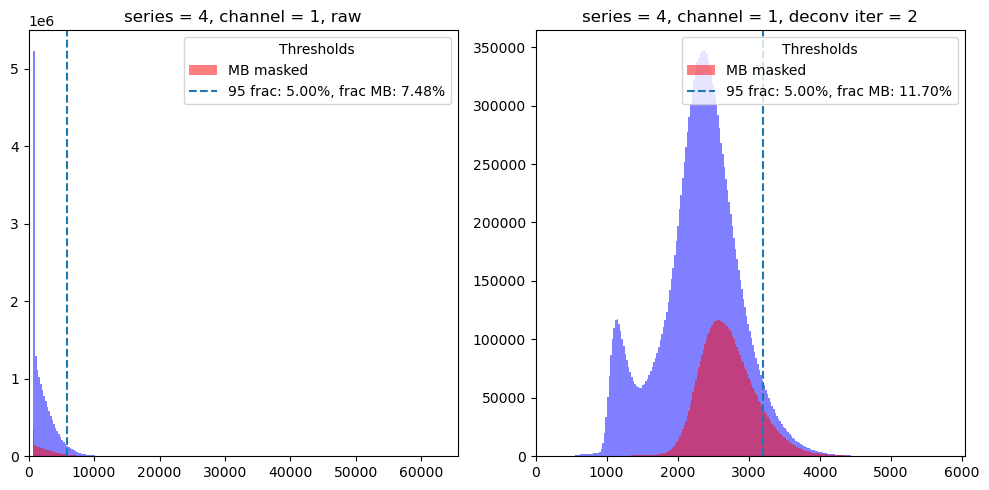

stack_deconv.shape: (66, 512, 512), MB_mask.shape: (66, 512, 512), stack_raw.shape: (66, 512, 512)


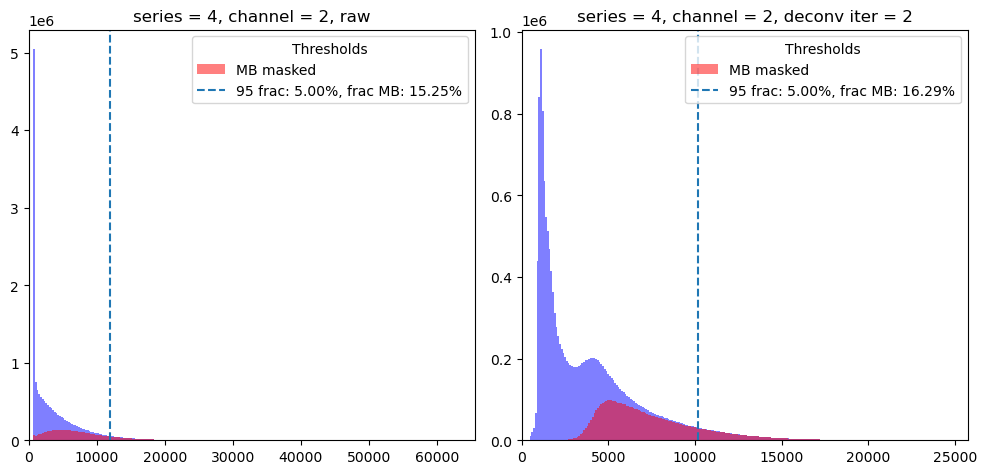

Processing series 5---------------
Channel 0************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_5/channel_0/2026_06_25_s5_ch0.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_5/channel_0/2026_06_25_s5_ch0_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_5/channel_0/2026_06_25_s5_ch0_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_5/channel_0/2026_06_25_s5_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_5/channel_1/2026_06_25_s5_ch1.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_5/channel_1/2026_06_25_s5_ch1_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_5/channel_1/2026_06_25_s5_ch1_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina

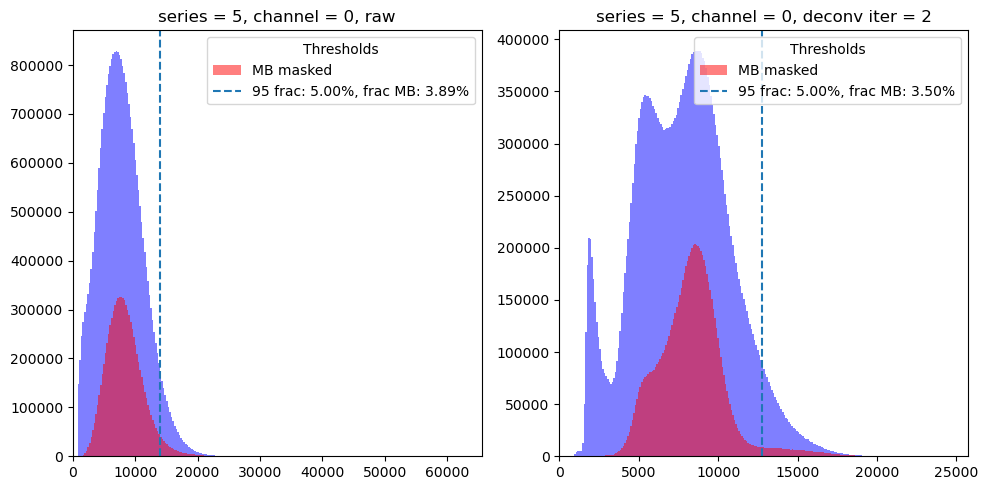

stack_deconv.shape: (112, 512, 512), MB_mask.shape: (112, 512, 512), stack_raw.shape: (112, 512, 512)


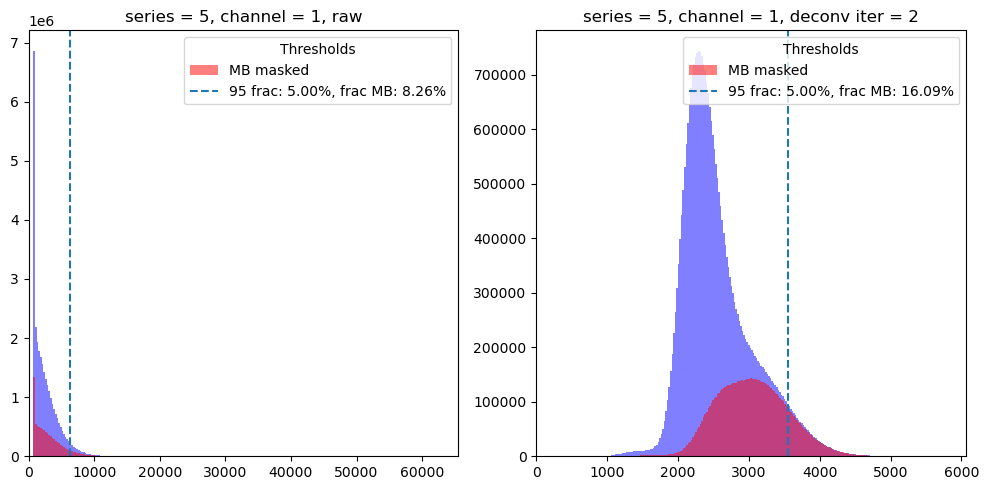

stack_deconv.shape: (112, 512, 512), MB_mask.shape: (112, 512, 512), stack_raw.shape: (112, 512, 512)


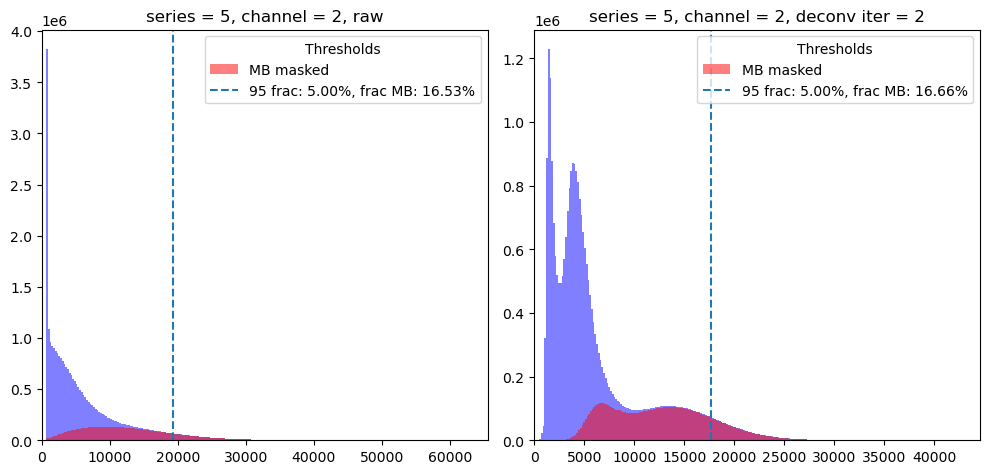

Processing series 7---------------
Channel 0************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_7/channel_0/2026_06_25_s7_ch0.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_7/channel_0/2026_06_25_s7_ch0_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_7/channel_0/2026_06_25_s7_ch0_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_7/channel_0/2026_06_25_s7_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_7/channel_1/2026_06_25_s7_ch1.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_7/channel_1/2026_06_25_s7_ch1_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_7/channel_1/2026_06_25_s7_ch1_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina

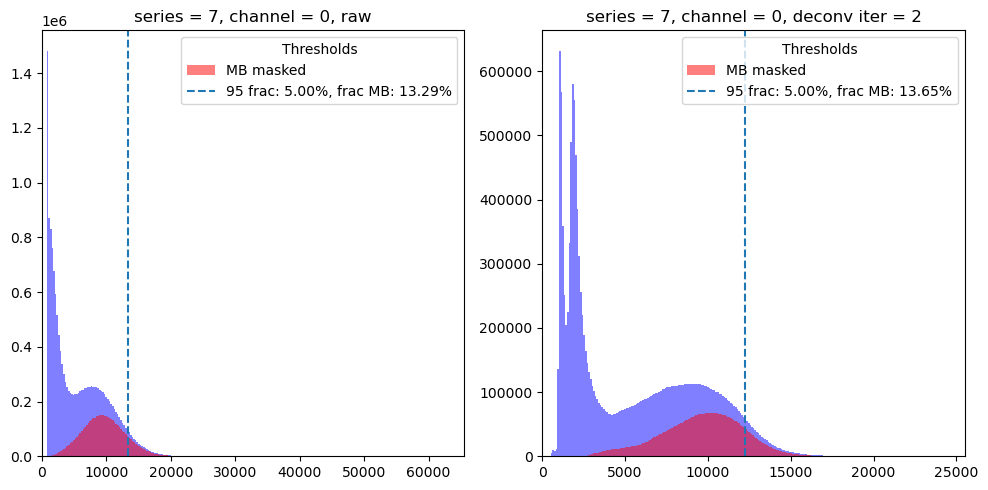

stack_deconv.shape: (62, 512, 512), MB_mask.shape: (62, 512, 512), stack_raw.shape: (62, 512, 512)


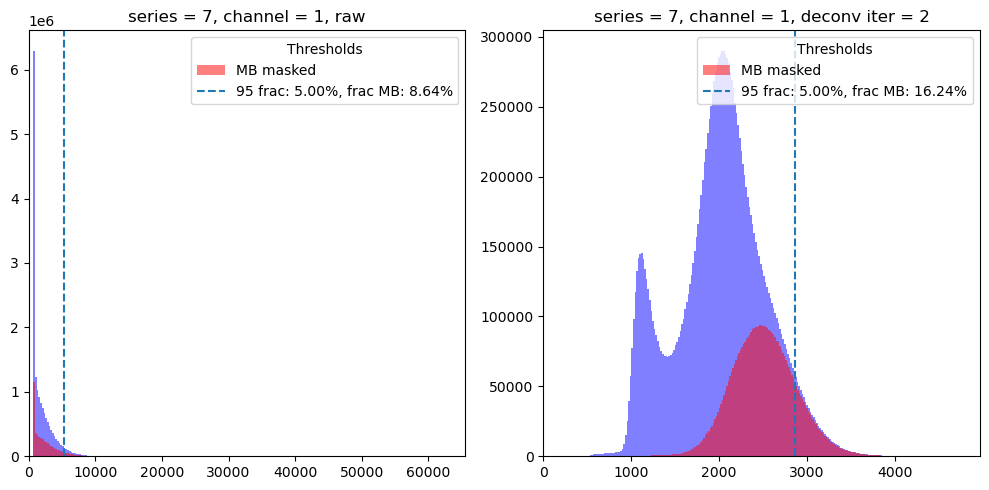

stack_deconv.shape: (62, 512, 512), MB_mask.shape: (62, 512, 512), stack_raw.shape: (62, 512, 512)


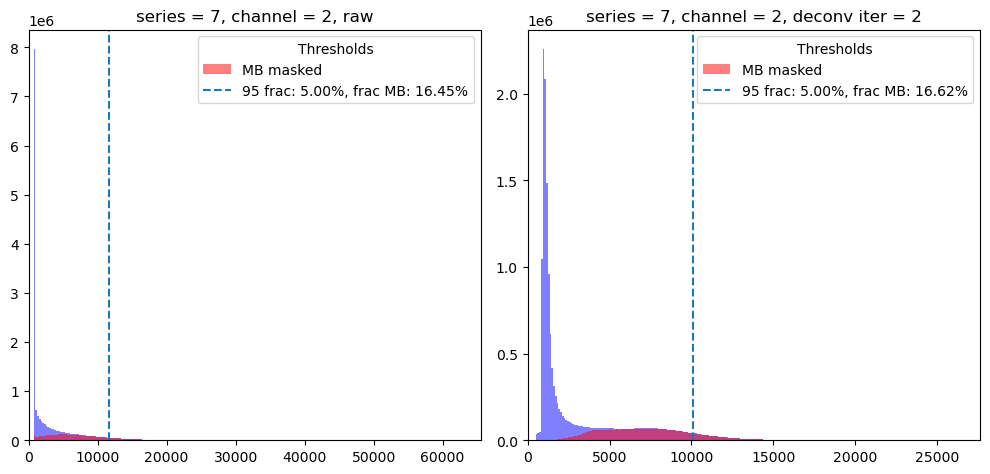

Processing series 8---------------
Channel 0************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_8/channel_0/2026_06_25_s8_ch0.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_8/channel_0/2026_06_25_s8_ch0_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_8/channel_0/2026_06_25_s8_ch0_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_8/channel_0/2026_06_25_s8_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_8/channel_1/2026_06_25_s8_ch1.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina/series_8/channel_1/2026_06_25_s8_ch1_masks_95.tif
deconv_iter_2 ************************
/Users/gerard/data/confocal/2026_06_25_Carmina/series_8/channel_1/2026_06_25_s8_ch1_deconv2d_iter_2.tif
saved /Users/gerard/data/confocal/2026_06_25_Carmina

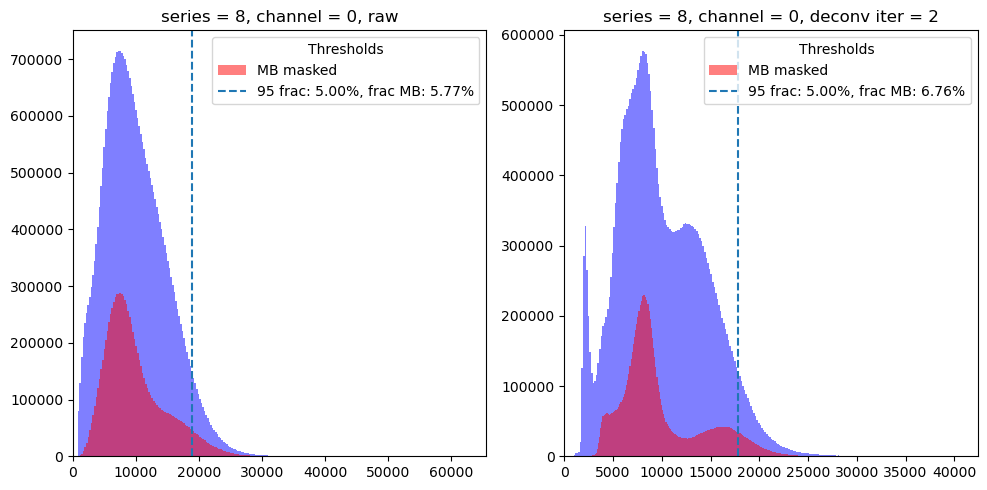

stack_deconv.shape: (127, 512, 512), MB_mask.shape: (127, 512, 512), stack_raw.shape: (127, 512, 512)


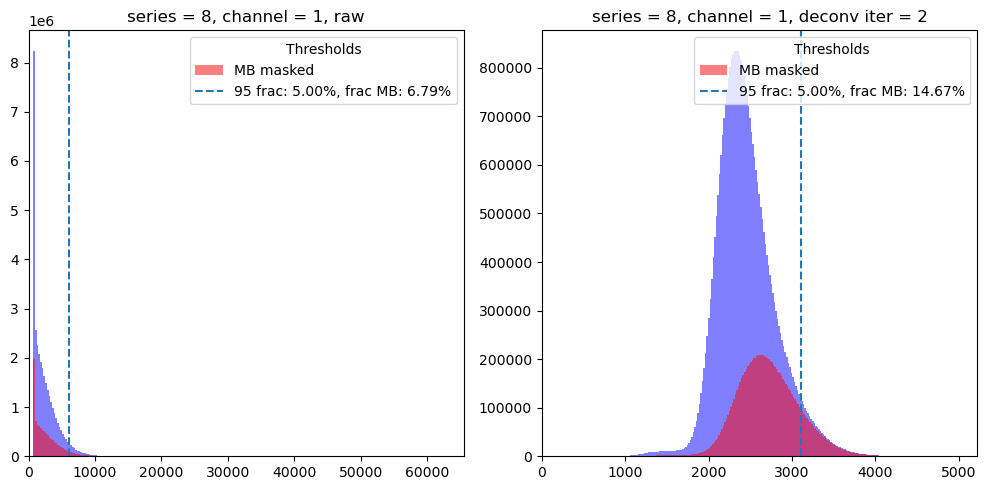

stack_deconv.shape: (127, 512, 512), MB_mask.shape: (127, 512, 512), stack_raw.shape: (127, 512, 512)


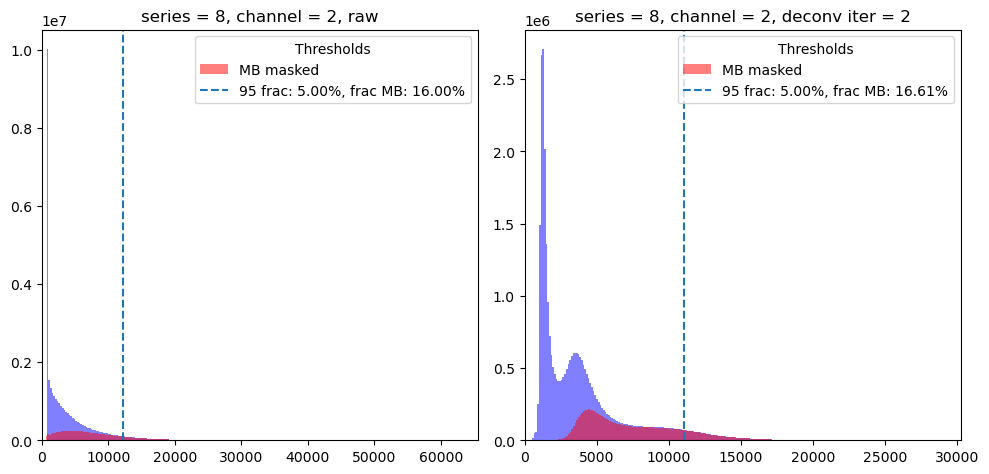

In [11]:
#thresholding(date, user, series_list, deconv_iter_list, do_plot = True )
#scenes = list(range(len(info.keys())))

#print(list(range(len(info.keys()))))

series_list = [0,1,4,5,7,8]# list(range(len(info.keys())))

# series_list = [9]
# selected_series = series_list[0]
results = thresholding(date, user, series_list, [2], channel_struct =2, do_plot = True )

## store results to do not have to run the whole thing again:


In [12]:
path_results = home + date + '_' + user + '/results.pkl' #'/media/data/connectome/KC/some_results/lists_results.pkl'
with open(path_results, 'wb') as f:
    pickle.dump(results, f)

## load the results:

In [10]:
path_results = home + date + '_' + user + '/results.pkl' #'/media/data/connectome/KC/some_results/lists_results.pkl'
#name_lists_results ='/media/data/connectome/KC/some_results/lists_results.pkl'
with open(path_results, 'rb') as f:
    results = pickle.load(f)


In [13]:
print_dict_structure(results)

└─ s_0 (dict):
  └─ c_0 (dict):
    └─ raw (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
    └─ deconv_iter_2 (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
  └─ c_1 (dict):
    └─ raw (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
    └─ deconv_iter_2 (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
  └─ c_2 (dict):
    └─ raw (dict):
      └─ stack (nda

## Understanding the colocalization metrics

To ask whether two proteins occupy the same pixels in the image, we threshold each channel to obtain a binary mask — pixels are either positive (signal present) or negative (signal absent). All three metrics below are computed within a defined region of interest (e.g. the Mushroom Body).

---

### Directional overlap fractions (binary Manders coefficients)

These answer: *of all pixels positive for protein A, what fraction are also positive for protein B?* And vice versa.

- **Fraction of A in B** = |A∩B| / |A| — "what fraction of A pixels have B signal?"
- **Fraction of B in A** = |A∩B| / |B| — "what fraction of B pixels have A signal?"

These are directional: they can be different from each other. For example, if mitochondria are large and HSP70 is a small subset that sits on them, the fraction of HSP in Mito will be high (most HSP is on mitochondria), while the fraction of Mito in HSP will be lower (mitochondria are big, and only part of their surface has HSP).

---

### Enrichment over random

The overlap fractions alone do not tell you whether the co-localization is *more than expected by chance*. If 80% of pixels in a region are Mito-positive and 70% are HSP-positive, you would expect ~56% overlap purely by random spatial overlap, regardless of any physical association.

The enrichment corrects for this:

**Enrichment = observed overlap / expected random overlap**

where the expected overlap is calculated assuming the two signals are distributed independently within the region. An enrichment of 1.0 means no association beyond chance; an enrichment of 6× means the two proteins co-localize six times more than would be predicted if they were independently distributed.

---

### Odds ratio

The odds ratio (OR) is the most statistically rigorous of the three. It asks: *how much more likely is a pixel to be B-positive if it is A-positive, compared to if it is A-negative?*

- **OR = 1**: knowing a pixel is A-positive gives no information about B — the two signals are independent
- **OR > 1**: A-positive pixels are more likely to carry B signal — positive co-localization
- **OR = 52**: an A-positive pixel is 52 times more likely to also be B-positive than an A-negative pixel

The OR is accompanied by a p-value. With microscopy images (thousands of pixels), p-values are almost always effectively zero — what matters is the **size of the OR**, not whether p < 0.05. An OR of 2 is meaningful; an OR of 900 is dramatic.

---

### Using the three metrics together

| Metric | What it tells you |
|---|---|
| Fraction A in B | How much of A is "covered" by B |
| Fraction B in A | How much of B is "covered" by A |
| Enrichment | Is co-localization above what chance would produce? |
| Odds ratio | How strongly are A and B spatially associated? |

A complete interpretation uses all three: the fractions describe the *extent* of overlap, the enrichment shows whether it is *above chance*, and the odds ratio quantifies the *strength of association* independently of how prevalent each signal is.


In [14]:
from scipy.stats import fisher_exact
import pandas as pd

#series_list = list(range(len(info.keys())))
table_results = {}
table_results['name'] = []
table_results['mask_HSP'] = []
table_results['mask_mito'] = []    
table_results['mask_BRP'] = []

for series in series_list:
    #print(list(info.keys())[series])
    
    
    
    channels = {
        '0':'BRP',
        '1':'HSP',
        '2':'Mito',    
    }

    comparisons = [
                # [0,1],
                # [0,2],
                [1,2],
                ]

    deconv_iter = 2

    chA_thrsh_al = '95'# ch1,HSP
    chB_thrsh_al = '95'# ch2,Mito
    brp_thrsh_al = '95' # ch0,BRP

    table_results['name'].append(list(info.keys())[series])
    table_results['mask_HSP'].append(chA_thrsh_al)
    table_results['mask_mito'].append(chB_thrsh_al)
    table_results['mask_BRP'].append(brp_thrsh_al)
    #************************************************************
    deconv_str_mask = 'deconv_iter_'+ str(deconv_iter)

    MB_mask = results['s_'+str(series)]['c_2'][deconv_str_mask]['mb'].astype(bool)
    brp_mask = results['s_'+str(series)]['c_0'][deconv_str_mask][brp_thrsh_al]['masks'].astype(bool)

    SYN_mask = MB_mask & brp_mask
    NON_SYN_mask = MB_mask & ~brp_mask
    for c in comparisons:
        
        chA_n = c[0]
        chB_n = c[1]


        mask_chA = results['s_'+str(series)]['c_'+str(chA_n)][deconv_str_mask][chA_thrsh_al]['masks'].astype(bool)
        mask_chB = results['s_'+str(series)]['c_'+str(chB_n)][deconv_str_mask][chB_thrsh_al]['masks'].astype(bool)
            
        
        
        masks2check = {'MB_total': MB_mask,
                    'MB_syn': SYN_mask,
                    'MB_non_syn' : NON_SYN_mask,
                    }
        
        for msk in masks2check.keys():
            #print(msk)
            MASK = masks2check[msk]
            
            
            mask_chA_MB = mask_chA & MASK
            mask_chB_MB = mask_chB & MASK
            overlap = mask_chA_MB & mask_chB_MB # |A∩B|
            
           ############
            A_and_B  = (mask_chA_MB &  mask_chB_MB).sum()
            A_not_B  = (mask_chA_MB & ~mask_chB_MB).sum()
            B_not_A  = (~mask_chA_MB & mask_chB_MB).sum()
            neither  = MASK.sum() - A_and_B - A_not_B - B_not_A  # fixed


            table = [[A_and_B, A_not_B],
                    [B_not_A, neither]]

            odds_ratio, pvalue = fisher_exact(table, alternative='greater') 

            
            
            ##############

            fraction_A_in_B = overlap.sum() / mask_chA_MB.sum()   # = |A∩B| / |A|:  "fraction of A that is B-positive"
            fraction_B_in_A = overlap.sum() / mask_chB_MB.sum()   # = |A∩B| / |B|:  "fraction of A that is B-positive"

            # print(f'fraction of {channels[str(chA_n)]} in {channels[str(chB_n)]}: {fraction_A_in_B:.2f}')
            # print(f'fraction of {channels[str(chB_n)]} in {channels[str(chA_n)]}: {fraction_B_in_A:.2f}')
            # print(f"odds ratio: {odds_ratio:.2f}")#, p = {pvalue:.2e}")

            
            pA = mask_chA_MB.sum() / MASK.sum()
            pB = mask_chB_MB.sum() / MASK.sum()

            # Expected overlap:
            observed = overlap.sum()
            expected = pA * pB * MASK.sum()

            #print(f'observed={observed}, expected={expected:.2f}')
            #print (f'the observed enrichment is {(observed/expected):.2f} bigger than expected.')
           
            column1 = msk + '_' +f'fraction of {channels[str(chA_n)]} in {channels[str(chB_n)]}'
            column2 = msk + '_' +f'fraction of {channels[str(chB_n)]} in {channels[str(chA_n)]}'
            column3 = msk + '_' + 'odds_ratio'
            column4 = msk + '_' + 'enrichment'
            
            if column1 not in table_results.keys():
                table_results[column1] = []
            if column2 not in table_results.keys():
                table_results[column2] = []
            if column3 not in table_results.keys():
                table_results[column3] = []
            if column4 not in table_results.keys(): 
                table_results[column4] = []
            
            table_results[column1].append(float(f'{fraction_A_in_B:.3f}'))
            table_results[column2].append(float(f'{fraction_B_in_A:.3f}'))
            table_results[column3].append(float(f'{odds_ratio:.3f}'))
            table_results[column4].append(float(f'{(observed/expected):.3f}'))
            

            
            #print(f'{fraction_A_in_B:.2f},{fraction_B_in_A:.2f},{odds_ratio:.2f},{(observed/expected):.2f}')
            
            
            #print('******************************')
            
#print(table_results.keys())
path_csv = home + date + '_' + user + '/coloc_results.csv' #'/media/data/connectome/KC/some_results/lists_results.pkl'

df = pd.DataFrame(table_results)
#print(df.to_csv(index=False))
df.to_csv(path_csv, index=False)
    


In [15]:
from scipy.stats import spearmanr

def snr_proxy(stack, p95_thresh=None):
    """(p95 - median) / std of background (voxels <= median).

    Proxy for how far the fixed-percentile mask threshold sits above the
    background noise floor, in background-sigma units. Low values mean the
    '95th percentile' mask is not distinguishable from the tail of the
    background noise distribution.
    """
    stack = np.asarray(stack)
    median = np.median(stack)
    if p95_thresh is None:
        p95_thresh = np.percentile(stack, 95)
    bg = stack[stack <= median]
    std_bg = bg.std()
    return round((p95_thresh - median) / std_bg, 3)


snr_rows = []
for series in series_list:
    name = list(info.keys())[series]
    row = {'name': name}
    for c_str, c_name in channels.items():
        entry = results['s_' + str(series)]['c_' + c_str][deconv_str_mask]
        row[f'snr_{c_name}'] = snr_proxy(entry['stack'], entry['95']['threshold'])
    snr_rows.append(row)

df_snr = pd.DataFrame(snr_rows)

df = pd.read_csv(path_csv)
df = df.merge(df_snr, on='name')

for c in comparisons:
    chA_name = channels[str(c[0])]
    chB_name = channels[str(c[1])]
    snr_col = f'snr_min_{chA_name}_{chB_name}'
    df[snr_col] = df[[f'snr_{chA_name}', f'snr_{chB_name}']].min(axis=1)

    for metric in ['MB_total_odds_ratio', 'MB_total_enrichment']:
        r, p = spearmanr(df[snr_col], df[metric])
        print(f'Spearman({snr_col}, {metric}) = {r:.3f} (p={p:.3f})')

df.to_csv(path_csv, index=False)
df.sort_values(list(df.filter(like='snr_min').columns)[0], ascending=False)


Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = 0.657 (p=0.156)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = 0.714 (p=0.111)


,name,mask_HSP,mask_mito,mask_BRP,MB_total_fraction of HSP in Mito,MB_total_fraction of Mito in HSP,MB_total_odds_ratio,MB_total_enrichment,MB_syn_fraction of HSP in Mito,MB_syn_fraction of Mito in HSP,MB_syn_odds_ratio,MB_syn_enrichment,MB_non_syn_fraction of HSP in Mito,MB_non_syn_fraction of Mito in HSP,MB_non_syn_odds_ratio,MB_non_syn_enrichment,snr_BRP,snr_HSP,snr_Mito,snr_min_HSP_Mito
3,dec02_1x_brain2gamma_L16,95,95,95,0.673,0.650,27.625,4.042,0.288,0.742,102.584,19.707,0.677,0.650,26.886,3.931,2.983,5.995,12.609,5.995
5,dec02_1x_brain2gamma_R16,95,95,95,0.627,0.554,17.705,3.776,0.074,0.657,26.322,9.037,0.647,0.554,17.740,3.641,4.371,3.977,15.704,3.977
0,dec02_1x_brain1alpha_R16,95,95,95,0.641,0.634,23.085,3.897,0.622,0.748,18.753,2.693,0.649,0.600,24.411,4.288,22.064,3.487,53.101,3.487
1,dec02_1x_brain1alphaprime_R16,95,95,95,0.636,0.631,22.686,3.914,0.574,0.723,17.976,3.002,0.656,0.609,24.621,4.178,6.034,3.314,21.648,3.314
4,dec02_1x_brain2alphaprime_R16,95,95,95,0.612,0.598,18.193,3.682,0.658,0.683,10.766,2.057,0.594,0.568,19.151,4.186,8.298,2.470,61.263,2.470
2,dec02_1x_brain2alphaprime_L16,95,95,95,0.608,0.437,13.353,3.730,0.611,0.575,17.517,3.731,0.607,0.415,12.881,3.729,3.025,2.116,12.613,2.116


## Is the SNR-vs-colocalization correlation biology or a noise artifact? A calibration check

The Spearman correlation above shows SNR and odds ratio moving together, but that pattern is also exactly what **pure noise-driven attenuation toward the null** predicts, with zero real biological difference between brains (non-differential misclassification of both channel masks biases odds ratio/enrichment toward 1 as noise increases).

To get a noise-only reference, we take the sample with the best HSP/Mito SNR (the one we trust most), and progressively add synthetic Gaussian noise to its two channels, recomputing the same 95th-percentile mask -> odds ratio/enrichment pipeline at each noise level. Because the underlying true image never changes, any change across noise levels is coming from noise alone — this is what "colocalization" would look like if the true biology were held constant and only measurement noise varied.

We then interpolate each real brain's own SNR onto this noise-only curve to get `MB_total_odds_ratio_noise_null`: the odds ratio expected at that brain's SNR if it had the reference brain's true biology and its lower measured value were pure artifact. The ratio of the actual measured value to this expectation (`MB_total_odds_ratio_excess_ratio`):
- **~1** — fully consistent with noise-only attenuation; no evidence this brain differs biologically from the reference.
- **> 1** — more colocalization than noise alone would produce at that SNR — evidence of a real signal beyond the artifact.
- **< 1** — less colocalization than even pure noise would give — worth a closer look (could be a genuine biological difference, or an unrelated problem with that sample).

**Caveat:** this assumes every brain's true biology matches the reference brain and that lower-SNR brains are just "reference + more noise." That's a strong simplification (real brains differ in more than noise), so treat this as a lower bound / sanity check on how much noise alone can distort the metric, not a hard correction.

In [ ]:
np.random.seed(0)

def add_gaussian_noise(stack, sigma):
    if sigma == 0:
        return stack.astype(np.float32)
    return stack.astype(np.float32) + np.random.normal(0, sigma, size=stack.shape).astype(np.float32)

def coloc_stats(stack_A, stack_B, MASK, percentile=95):
    """Same odds-ratio/enrichment formulas as the main coloc cell, computed directly from raw stacks."""
    mask_A = (stack_A > np.percentile(stack_A, percentile)) & MASK
    mask_B = (stack_B > np.percentile(stack_B, percentile)) & MASK

    A_and_B = (mask_A & mask_B).sum()
    A_not_B = (mask_A & ~mask_B).sum()
    B_not_A = (~mask_A & mask_B).sum()
    neither = MASK.sum() - A_and_B - A_not_B - B_not_A

    odds_ratio, _ = fisher_exact([[A_and_B, A_not_B], [B_not_A, neither]], alternative='greater')

    pA = mask_A.sum() / MASK.sum()
    pB = mask_B.sum() / MASK.sum()
    expected = pA * pB * MASK.sum()
    enrichment = A_and_B / expected

    return odds_ratio, enrichment

# --- reference sample: the one with the best HSP/Mito SNR already in df ---
ref_name = df.sort_values('snr_min_HSP_Mito', ascending=False)['name'].iloc[0]
ref_series = series_list[list(info.keys()).index(ref_name)]
print(f'Calibrating on reference sample: {ref_name} (series {ref_series})')

ref_HSP  = results['s_' + str(ref_series)]['c_1'][deconv_str_mask]['stack'].astype(np.float32)
ref_Mito = results['s_' + str(ref_series)]['c_2'][deconv_str_mask]['stack'].astype(np.float32)
ref_MB   = results['s_' + str(ref_series)]['c_2'][deconv_str_mask]['mb'].astype(bool)

sigma0_HSP  = ref_HSP[ref_HSP <= np.median(ref_HSP)].std()
sigma0_Mito = ref_Mito[ref_Mito <= np.median(ref_Mito)].std()

# multiples of each channel's own background std, spanning down to the noisiest real sample's SNR
noise_levels = [0, 0.5, 1, 2, 3, 4, 6, 8, 12, 16, 24]

calib_rows = []
for k in noise_levels:
    noisy_HSP  = add_gaussian_noise(ref_HSP,  k * sigma0_HSP)
    noisy_Mito = add_gaussian_noise(ref_Mito, k * sigma0_Mito)

    snr_min_k = min(snr_proxy(noisy_HSP), snr_proxy(noisy_Mito))
    OR_k, enrich_k = coloc_stats(noisy_HSP, noisy_Mito, ref_MB)

    calib_rows.append({'noise_k': k, 'snr_min': snr_min_k, 'odds_ratio': OR_k, 'enrichment': enrich_k})

df_calib = pd.DataFrame(calib_rows).sort_values('snr_min').reset_index(drop=True)
print(df_calib)

# --- interpolate the noise-only curve onto each real sample's actual SNR ---
df['MB_total_odds_ratio_noise_null']   = np.interp(df['snr_min_HSP_Mito'], df_calib['snr_min'], df_calib['odds_ratio'])
df['MB_total_enrichment_noise_null']   = np.interp(df['snr_min_HSP_Mito'], df_calib['snr_min'], df_calib['enrichment'])
df['MB_total_odds_ratio_excess_ratio'] = df['MB_total_odds_ratio'] / df['MB_total_odds_ratio_noise_null']

df.to_csv(path_csv, index=False)
df[['name', 'snr_min_HSP_Mito', 'MB_total_odds_ratio', 'MB_total_odds_ratio_noise_null',
    'MB_total_odds_ratio_excess_ratio']].sort_values('snr_min_HSP_Mito', ascending=False)
